In [1]:
import numpy as np

# === FORWARD PASS ===
x = np.array([1.0, 2.0, 3.0])

W1 = np.array([[0.1,  0.2, -0.1,  0.3],
               [0.4, -0.2,  0.1,  0.1],
               [-0.1, 0.3,  0.2, -0.2]])

W2 = np.array([[ 0.2, -0.3],
               [ 0.1,  0.4],
               [-0.2,  0.1],
               [ 0.3, -0.1]])

z1    = x @ W1
h1    = np.maximum(0, z1)
z2    = h1 @ W2
exp_z = np.exp(z2 - z2.max())
probs = exp_z / exp_z.sum()

correct_class = 0

print("z1   :", z1)
print("h1   :", h1)
print("z2   :", z2)
print("probs:", probs)
print("Loss :", -np.log(probs[correct_class]))

z1   : [ 0.6  0.7  0.7 -0.1]
h1   : [0.6 0.7 0.7 0. ]
z2   : [0.05 0.17]
probs: [0.47003595 0.52996405]
Loss : 0.7549461015956136


In [2]:
one_hot = np.zeros(len(probs))
one_hot[correct_class] = 1

dL_dz2 = probs - one_hot

print("one_hot:", one_hot)
print("dL_dz2 :", dL_dz2)

one_hot: [1. 0.]
dL_dz2 : [-0.52996405  0.52996405]


In [3]:
dL_dW2 = np.outer(h1, dL_dz2)
print("dL_dW2 shape:", dL_dW2.shape)
print("dL_dW2:\n", dL_dW2)

dL_dW2 shape: (4, 2)
dL_dW2:
 [[-0.31797843  0.31797843]
 [-0.37097484  0.37097484]
 [-0.37097484  0.37097484]
 [-0.          0.        ]]


In [4]:
# Step 3: Gradient flowing back into h1 (before ReLU)
dL_dh1 = dL_dz2 @ W2.T

print("dL_dh1:", dL_dh1)
print("dL_dh1 shape:", dL_dh1.shape)   

dL_dh1: [-0.26498203  0.15898922  0.15898922 -0.21198562]
dL_dh1 shape: (4,)


In [5]:
# Step 4: Through ReLU
# Where z1 <= 0, gradient is blocked (set to 0)

dL_dz1 = dL_dh1.copy()
dL_dz1[z1 <= 0] = 0

print("z1    :", z1)
print("dL_dh1:", dL_dh1)
print("dL_dz1:", dL_dz1)   # position 3 should become 0!

z1    : [ 0.6  0.7  0.7 -0.1]
dL_dh1: [-0.26498203  0.15898922  0.15898922 -0.21198562]
dL_dz1: [-0.26498203  0.15898922  0.15898922  0.        ]


In [6]:
# Step 5: Gradient for W1
dL_dW1 = np.outer(x, dL_dz1)

print("dL_dW1 shape:", dL_dW1.shape)   # should be (3, 4) same as W1
print("dL_dW1:\n", dL_dW1)

dL_dW1 shape: (3, 4)
dL_dW1:
 [[-0.26498203  0.15898922  0.15898922  0.        ]
 [-0.52996405  0.31797843  0.31797843  0.        ]
 [-0.79494608  0.47696765  0.47696765  0.        ]]


In [7]:
# Step 6: Update weights (one gradient descent step)
lr = 0.1

W1 = W1 - lr * dL_dW1
W2 = W2 - lr * dL_dW2

# Check new loss
z1_new = x @ W1
h1_new = np.maximum(0, z1_new)
z2_new = h1_new @ W2
probs_new = np.exp(z2_new - z2_new.max()) / np.exp(z2_new - z2_new.max()).sum()
loss_new = -np.log(probs_new[correct_class])

print("Old loss:", -np.log(probs[correct_class]))
print("New loss:", loss_new)

Old loss: 0.7549461015956136
New loss: 0.5410162119518764


In [ ]:
###

In [8]:
def forward(x, W1, W2):
    """Forward pass. Returns probabilities and values needed for backward."""
    z1 = x @ W1
    h1 = np.maximum(0,z1)
    z2 = h1 @ W2
    exp_z = np.exp(z2 - z2.max())
    probs = exp_z / exp_z.sum()
    cache = (z1, h1) # save for ReLU mask and outer products
    return probs, cache

In [9]:
def backward(x, W1, W2, cache, probs, correct_class):
    """Backward pass. Returns gradients dL_dW1 and dL_dW2 (same shapes as W1, W2)."""
    z1, h1 = cache

    # step 1: softmax + cross-entropy
    one_hot = np.zeros(len(probs))
    one_hot[correct_class] = 1
    dL_dz2 = probs - one_hot

    # step 2: W2
    dL_dW2 = np.outer(h1, dL_dz2)

    # step 3: back into h1
    dL_dh1 = dL_dz2 @ W2.T

    # step 4: ReLu
    dL_dz1 = dL_dh1.copy()
    dL_dz1[z1 <= 0] = 0
    
    # step 5: W1
    dL_dW1 = np.outer(x, dL_dz1)

    return dL_dW1, dL_dW2

In [10]:
def train_step(x, W1, W2, correct_class, lr):
    """One full forward + backward + weight update."""
    probs, cache = forward(x, W1, W2)
    loss = -np.log(probs[correct_class] + 1e-9)
    dL_dW1, dL_dW2 = backward(x, W1, W2, cache, probs, correct_class)
    W1 = W1 - lr * dL_dW1
    W2 = W2 - lr * dL_dW2
    return loss, W1, W2, probs

In [12]:
# Reset weights to initial values (fresh training run)
W1_train = np.array([[0.1,  0.2, -0.1,  0.3],
                     [0.4, -0.2,  0.1,  0.1],
                     [-0.1, 0.3,  0.2, -0.2]])
W2_train = np.array([[ 0.2, -0.3],
                     [ 0.1,  0.4],
                     [-0.2,  0.1],
                     [ 0.3, -0.1]])

lr = 0.1
n_epochs = 200
losses = []

for epoch in range(n_epochs):
    loss, W1_train, W2_train, probs = train_step(x, W1_train, W2_train, correct_class, lr)
    losses.append(loss)
    if epoch % 20 == 0:
        pred_class = np.argmax(probs)
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | probs: {probs} | pred class: {pred_class}")

print(f"\nFinal loss: {losses[-1]:.4f} (started at {losses[0]:.4f})")


Epoch   0 | Loss: 0.7549 | probs: [0.47003595 0.52996405] | pred class: 1
Epoch  20 | Loss: 0.0169 | probs: [0.98322225 0.01677775] | pred class: 0
Epoch  40 | Loss: 0.0063 | probs: [0.99372148 0.00627852] | pred class: 0
Epoch  60 | Loss: 0.0037 | probs: [0.99634483 0.00365517] | pred class: 0
Epoch  80 | Loss: 0.0025 | probs: [0.99748241 0.00251759] | pred class: 0
Epoch 100 | Loss: 0.0019 | probs: [0.9981046 0.0018954] | pred class: 0
Epoch 120 | Loss: 0.0015 | probs: [0.99849237 0.00150763] | pred class: 0
Epoch 140 | Loss: 0.0012 | probs: [0.99875524 0.00124476] | pred class: 0
Epoch 160 | Loss: 0.0011 | probs: [0.99894421 0.00105579] | pred class: 0
Epoch 180 | Loss: 0.0009 | probs: [9.99086067e-01 9.13933097e-04] | pred class: 0

Final loss: 0.0008 (started at 0.7549)


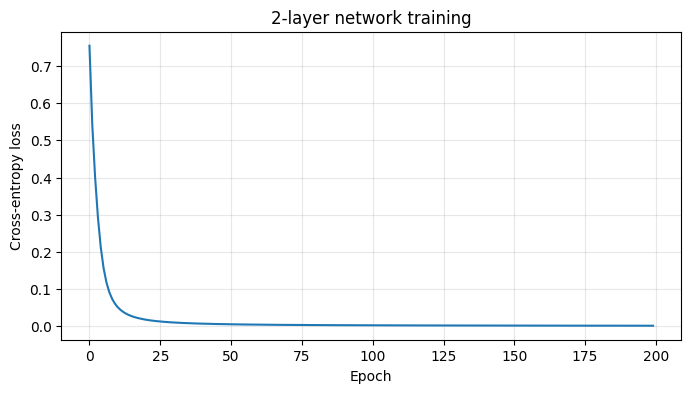

In [13]:
# Plot loss over epochs (optional: needs matplotlib)
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title("2-layer network training")
    plt.grid(True, alpha=0.3)
    plt.show()
except ImportError:
    print("matplotlib not installed — loss list is in variable `losses`")


In [14]:
# After training: what does the network predict?
probs_final, _ = forward(x, W1_train, W2_train)
pred_class = np.argmax(probs_final)
print("Target class:", correct_class)
print("Final probs :", probs_final)
print("Predicted   :", pred_class)
print("Correct?"    , "yes" if pred_class == correct_class else "no")


Target class: 0
Final probs : [9.99196166e-01 8.03833838e-04]
Predicted   : 0
Correct? yes
